In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


# Function to highlight maximum in red
def highlight_max_red(s):
    is_max = s == s.max()
    return ['color: red' if v else '' for v in is_max]

# Function to highlight minimum in red
def highlight_min_red(s):
    is_min = s == s.min()
    return ['color: red' if v else '' for v in is_min]

<div dir="rtl"> 

## רגרסיה פולינומית עם משתנים מרובים

## בדוגמא הקודמת התעסקנו עם  רגרסיה עם משתנה מסביר בודד. אבל מה אם יש יותר ממשתנה מסביר אחד? 

### נחשוב רגע למשל על מכירות של חברה, נניח שיש שני משתנים שחוזים את היקף המכירות

### 1. השקעה בפרסום
### 2. כמות אנשים שגרים באיזור של החנות

### ברור שאם אשקיע בפרסום זה לא יעזור יותר מדי אם יש מעט אנשים שגרים באיזור.

### נדגים ויזואלית איך זה מתבטא ונציג זאת מתמטית

### במודל שיש בו אינטראקציה בין שני משתנים זה ייראה כך:

### $$ Y = \beta_0  + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2 $$

### כלומר מכפלה בין שני משתנים

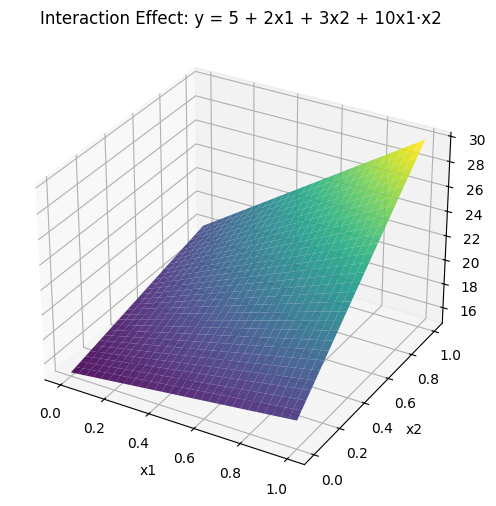

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulate data
x1 = np.linspace(0, 1, 30)
x2 = np.linspace(0, 1, 30)
X1, X2 = np.meshgrid(x1, x2)

# Interaction model: response depends on both x1 and x2 together
Y = 5 + 2 * X1 + 3 * X2 + 10 * X1 * X2+ 10 


# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Y, cmap='viridis', alpha=0.9)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Interaction Effect: y = 5 + 2x1 + 3x2 + 10x1·x2')
plt.show()


<div dir="rtl"> 

### נראה ויזאולית מה זה אומר שיש אינטראקציה בין שני המשתנים המסבירים

### עבור שלושה ערכים שונים של $X_1$  נציג את y כפונקציה של $X_2$

In [6]:
X2 = 0.25
x1_vals = np.linspace(0,1,50)
low_vals = 5 + 2 * x1_vals + 3 * X2 + 10 * x1_vals * X2+ 10 

X2 = 0.5
mid_vals = 5 + 2 * x1_vals + 3 * X2 + 10 * x1_vals * X2+ 10 

X2 = 0.75
high = 5 + 2 *x1_vals + 3 * X2 + 10 * x1_vals * X2+ 10 
high_vals = 5 + 2 * x1_vals + 3 * X2 + 10 * x1_vals * X2+ 10 

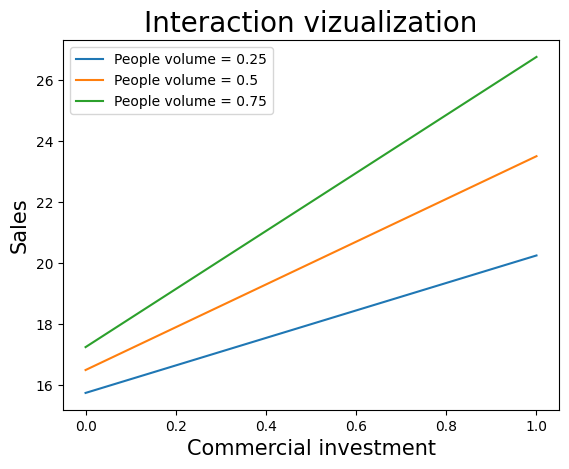

In [9]:
plt.figure()
plt.plot(x1_vals, low_vals, label = 'People volume = 0.25')
plt.plot(x1_vals, mid_vals, label = 'People volume = 0.5')
plt.plot(x1_vals, high_vals, label = 'People volume = 0.75')
plt.legend()
plt.xlabel('Commercial investment', fontsize = 15)
plt.title('Interaction vizualization', fontsize = 20)
plt.ylabel('Sales', fontsize = 15)
plt.show()

<div dir="rtl"> 

### איך יודעים שיש אינטראקציה?

### בגלל שהשיפועים שונים.

### פירוש הדבר שy משתנה כפונקציה של $X_2$ בצורה שונה עבור ערכים שונים של $X_1$.

### כשאין אינטרצאה זה נראה ככה

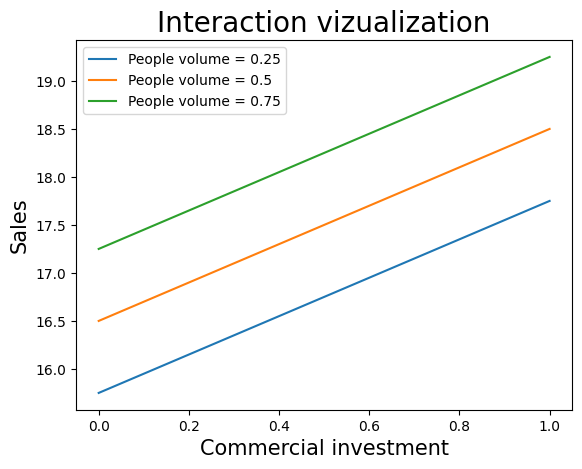

In [10]:
X2 = 0.25
x1_vals = np.linspace(0,1,50)
low_vals = 5 + 2 * x1_vals + 3 * X2+ 10 

X2 = 0.5
mid_vals = 5 + 2 * x1_vals + 3 * X2+ 10 

X2 = 0.75
high = 5 + 2 *x1_vals + 3 * X2 + 10 + 10 
high_vals = 5 + 2 * x1_vals + 3 * X2 + 10 

plt.figure()
plt.plot(x1_vals, low_vals, label = 'People volume = 0.25')
plt.plot(x1_vals, mid_vals, label = 'People volume = 0.5')
plt.plot(x1_vals, high_vals, label = 'People volume = 0.75')
plt.legend()
plt.xlabel('Commercial investment', fontsize = 15)
plt.title('Interaction vizualization', fontsize = 20)
plt.ylabel('Sales', fontsize = 15)
plt.show()

<div dir="rtl"> 

###    הקווים מקבילים  כלומר אין אינטראקציה 

## בדוגמא מקודם דיברנו רק על פולינום מסדר ראשון

### נסביר מה זה אומר מסדר ראשון ומסדר גבוה יותר

<div dir="rtl"> 


# רגרסיה פולינומית רב־משתנית עם Statsmodels





<div dir="rtl">  


## 📘 סיפור: חיזוי שכר לפי ניסיון ומחלקה

### אתה חוקר נתונים בחברת טכנולוגיה.  
### המטרה: להבין כיצד **שנות ניסיון** ו**מחלקה** משפיעים על **השכר החודשי** של עובדים.


###  הנתונים כוללים:

### - `experience` — שנות ניסיון (מספר רציף)
### - `department` — מחלקה: "Engineering" או "Marketing"
### - `salary` — שכר חודשי בדולרים


In [11]:


# שלב 1: יצירת נתונים מדומים
np.random.seed(42)
n = 100
experience = np.random.uniform(1, 10, size=n)
department = np.random.choice(['Engineering', 'Marketing'], size=n)

# נוסחת שכר: מחלקת הנדסה מרוויחה יותר מכל שנת ניסיון
salary = (4000 + 500 * experience) * (department == 'Engineering') + \
         (3500 + 300 * experience) * (department == 'Marketing') + \
         np.random.normal(0, 200, size=n)

df = pd.DataFrame({
    'experience': experience,
    'department': department,
    'salary': salary
})
df.head()

,experience,department,salary
0,4.370861,Engineering,6146.958342
1,9.556429,Marketing,6427.238096
2,7.587945,Engineering,7787.030384
3,6.387926,Engineering,6960.227571
4,2.404168,Marketing,4449.814892


<div dir="rtl">  

### כשעובדים עם stat models אז צריך שמשתנים קטגוראילים יהיו בולייאנים


In [12]:
df_encoded = pd.get_dummies(df, columns=['department'], drop_first=True)

df_encoded['department_Marketing'] = df_encoded['department_Marketing'].astype(int)
df_encoded.head()

,experience,salary,department_Marketing
0,4.370861,6146.958342,0
1,9.556429,6427.238096,1
2,7.587945,7787.030384,0
3,6.387926,6960.227571,0
4,2.404168,4449.814892,1


(100, 10)

<div dir="rtl">  

### נוסיף אינטראקציה בין ניסיון ומחלקה.

###  נעשה את זה על ידי שימוש בPolynomialFeatures

### כלומר נשתמש במודל מהסוג:

### $$ Y = \beta_0  + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2 $$



In [25]:
poly = PolynomialFeatures(degree=2,interaction_only=True)
X_train_poly = poly.fit_transform(df_encoded[['experience', 'department_Marketing']])
X_train_poly[:3,:]

array([[1.        , 4.37086107, 0.        , 0.        ],
       [1.        , 9.55642876, 1.        , 9.55642876],
       [1.        , 7.58794548, 0.        , 0.        ]])

<div dir="rtl">  

##  קידוד של מודל בstatmodels

### אם נרצה שיהיה לנו מודל עם אינטראקציה נזין degree=2, interaction_only=True

### אם נזין interaction_only=False יחד עם degree=2 נקבל:

### $$ Y = \beta_0  + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1^2 + \beta_4 X_2^2 + \beta_5 X_1 X_2  $$

In [24]:
poly = PolynomialFeatures(degree=3,interaction_only=False)
X_train_poly = poly.fit_transform(df_encoded[['experience', 'department_Marketing']])
X_train_poly[:1,:]

array([[ 1.        ,  4.37086107,  0.        , 19.10442649,  0.        ,
         0.        , 83.502794  ,  0.        ,  0.        ,  0.        ]])

<div dir="rtl">  




### במקרה הזה אנחנו רק רוצים לבחון את האינטראקציה

### נעשה Interaction_only= True

In [33]:
poly = PolynomialFeatures(degree=2,interaction_only=True, include_bias=True)
X_train_poly = poly.fit_transform(df_encoded[['experience', 'department_Marketing']])
X_train_poly.shape

(100, 4)

In [34]:
X_train_poly[:5,:]

array([[1.        , 4.37086107, 0.        , 0.        ],
       [1.        , 9.55642876, 1.        , 9.55642876],
       [1.        , 7.58794548, 0.        , 0.        ],
       [1.        , 6.38792636, 0.        , 0.        ],
       [1.        , 2.40416776, 1.        , 2.40416776]])

<div dir="rtl">  

### נכניס שמות  לעמודות כדי שיהיה יותר קל לעקוב אחרי התוצאות

In [35]:
feature_names

array(['1', 'experience', 'department_Marketing',
       'experience department_Marketing'], dtype=object)

In [36]:
# Get the feature names
feature_names = poly.get_feature_names_out()

# Create a new DataFrame with column names
X_train_poly_df = pd.DataFrame(X_train_poly, columns=feature_names)

X_train_poly_df

,1,experience,department_Marketing,experience department_Marketing
0,1.0,4.370861,0.0,0.000000
1,1.0,9.556429,1.0,9.556429
2,1.0,7.587945,0.0,0.000000
3,1.0,6.387926,0.0,0.000000
4,1.0,2.404168,1.0,2.404168
...,...,...,...,...
95,1.0,5.444160,1.0,5.444160
96,1.0,5.704595,1.0,5.704595
97,1.0,4.847869,0.0,0.000000
98,1.0,1.228772,0.0,0.000000


<div dir="rtl">  

### נבנה את המודל

In [37]:
# Fit model
model = sm.OLS(df_encoded['salary'],X_train_poly_df).fit()
# שלב 2: התאמת רגרסיה ליניארית עם statsmodels
# שלב 3: הדפסת סיכום המודל
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1538.
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           5.51e-81
Time:                        15:22:41   Log-Likelihood:                -668.27
No. Observations:                 100   AIC:                             1345.
Df Residuals:                      96   BIC:                             1355.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
1         

<div dir="rtl">  

### כל המשתנים יצאו מובהקים

### מקדם האינטראקציה הוא 

### $$ -213.8698 $$

<div dir="rtl">  

# אבל איך מפרשים את המקדם הזה? 


## ננסה לתת דוגמה

### נניח שיש לנו את המודל:

### $$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 (x_1 \cdot x_2) $$


### $\beta_0$: החיתוך (intercept).  
### $\beta_1$: ההשפעה של $x_1$ כאשר  $x_2 = 0$.  
### $\beta_2$: ההשפעה של $x_2$ כאשר $x_1 = 0$.  
###  $\beta_3$: **מקדם האינטראקציה** – מייצג עד כמה השיפוע של משתנה אחד תלוי בערך של המשתנה השני.

---

## איך מפרשים את $\beta_3$?
### ההשפעה השולית של $x_1$ על $y$ היא:

### $$ \frac{\partial y}{\partial x_1} = \beta_1 + \beta_3 x_2 $$

###  כלומר השיפוע של $x_1$ תלוי בערך של $x_2$.

###  באותו אופן, ההשפעה השולית של $x_2$ על $y$ היא:

### $$ \frac{\partial y}{\partial x_2} = \beta_2 + \beta_3 x_1 $$

---

## הסבר במילים פשוטות
### אם $\beta_3 = 0$: ההשפעות של $x_1$ ו-$x_2$ הן נפרדות וחיבוריות בלבד.  
### אם $\beta_3 > 0$: המשתנים **מחזקים זה את זה** – הגדלת אחד מהם מגדילה את ההשפעה של השני.  
### אם $\beta_3 < 0$: המשתנים **מחלישים זה את זה** – הגדלת אחד מהם מקטינה את ההשפעה של השני.  

---



## דוגמה

### נניח:

### $$ y = 2 + 1\cdot x_1 + 0.5\cdot x_2 + 0.3\cdot (x_1 x_2) $$

### אם $x_2 = 0$, אז השיפוע ביחס ל-$x_1$ הוא 1 .  
### אם $x_2 = 2$, אז השיפוע ביחס ל-$x_1$ הוא:


### $$ 1 + 0.3 \cdot 2 = 1.6 $$ 

### כלומר, ההשפעה של $x_1$ **גדלה** כאשר הערך של $x_2$  עולה.  




In [10]:
X_train_poly_df

,1,experience,department_Marketing,experience department_Marketing
0,1.0,4.370861,0.0,0.000000
1,1.0,9.556429,1.0,9.556429
2,1.0,7.587945,0.0,0.000000
3,1.0,6.387926,0.0,0.000000
4,1.0,2.404168,1.0,2.404168
...,...,...,...,...
95,1.0,5.444160,1.0,5.444160
96,1.0,5.704595,1.0,5.704595
97,1.0,4.847869,0.0,0.000000
98,1.0,1.228772,0.0,0.000000


<div dir="rtl">  

### נציג ויזואלית 

In [12]:
y_preds = model.predict(X_train_poly_df)

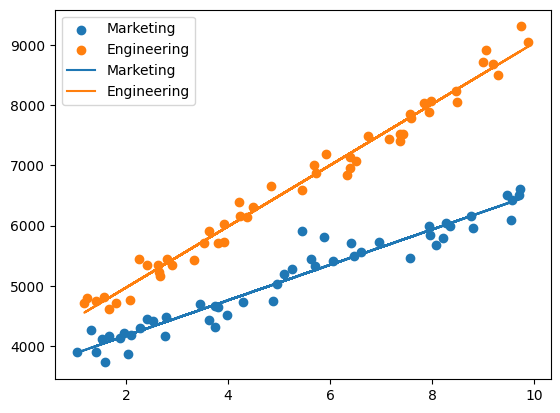

In [13]:
plt.figure()
plt.scatter(X_train_poly_df.loc[X_train_poly_df['department_Marketing']==1, 'experience'], df.loc[df['department']=='Marketing', 'salary'], label = 'Marketing')
plt.scatter(X_train_poly_df.loc[X_train_poly_df['department_Marketing']==0, 'experience'], df.loc[df['department']=='Engineering', 'salary'], label = 'Engineering')
plt.plot(X_train_poly_df.loc[X_train_poly_df['department_Marketing']==1, 'experience'], y_preds[X_train_poly_df['department_Marketing']==1], label = 'Marketing')
plt.plot(X_train_poly_df.loc[X_train_poly_df['department_Marketing']==0, 'experience'], y_preds[X_train_poly_df['department_Marketing']==0], label = 'Engineering')


plt.legend()
plt.show()

<div dir="rtl">  

## מה אנחנו יכולים ללמוד מזה? 

### ההשפעה של ניסיון על השכר יותר גדולה עבור מהנדסים ביחס לאנשי שיווק

<div dir="rtl">  

## אינטראקציות מסדר גדול יותר:

### $$ Y = \beta_0  + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1^2 + \beta_4 X_2^2 + \beta_5 X_1 X_2  $$


## ייתכן שהאינטראקציות אינן ליניאריות, או לא רק ליניאריות, לכן נרצה לבדוק את כל האופציות. 

### בדומגא הבאה ננסה לחזות הכנסות של חנות לפי כמות אנשים שעוברים ליד החנות, השקעה בפרסום וכמות מתחרים. 

In [40]:
# Section 2: Synthetic Data Generation
np.random.seed(0)
n = 300
foot_traffic = np.random.uniform(100, 1000, n)
ad_spend = np.random.uniform(500, 3000, n)
competitors = np.random.randint(0, 6, n)

# Nonlinear relationship with interactions
revenue = (
    500 + 0.8 * foot_traffic + 1.5 * ad_spend - 300 * competitors +
    0.002 * foot_traffic * ad_spend - 0.0003 * ad_spend**2 - 50 * competitors**2 +
    np.random.normal(0, 150, n)
)

X = np.column_stack((foot_traffic, ad_spend, competitors))

X_data = pd.DataFrame(X, columns =  ['foot_traffic', 'ad_spend', 'competitors'])

y = revenue.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.3, random_state=1)

X_train.head()

,foot_traffic,ad_spend,competitors
253,773.797258,1799.880936,1.0
19,883.010933,2317.610657,5.0
14,163.932452,2180.119518,3.0
91,700.669342,1560.080630,2.0
296,188.060036,1405.472647,1.0


<div dir="rtl">  

## עכשיו נאחד אינטראקציה עם רגרסיה פולינומית.
 

## אינטראקציות מסדר גדול יותר:

### $$ Y = \beta_0  + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1^2 + \beta_4 X_2^2 + \beta_5 X_1 X_2  $$


## ייתכן שהאינטראקציות אינן ליניאריות, או לא רק ליניאריות, לכן נרצה לבדוק את כל האופציות. 

### כאשר מתחשבים באינטראקציות מסדר גדול יותר יש הרבה יותר משתנים.

### נראה עבוד שלושה משתנים מסבירים לכמה זה מסתכם אם עושים רגרסיה פולינומית עם אינטראקציות מסדר n

In [46]:
num_fetures = []
for degree in range(1,11):
    poly = PolynomialFeatures(degree=degree, interaction_only = False)
    X_train_poly = poly.fit_transform(X_train)
    feature_names = poly.get_feature_names_out(X_train.columns)
    df_X_train = pd.DataFrame(X_train_poly, columns= feature_names)
    print('Degree, ', degree, 'Number of ploynomial features',  df_X_train.shape[1])
    num_fetures.append(df_X_train.shape[1])

Degree,  1 Number of ploynomial features 4
Degree,  2 Number of ploynomial features 10
Degree,  3 Number of ploynomial features 20
Degree,  4 Number of ploynomial features 35
Degree,  5 Number of ploynomial features 56
Degree,  6 Number of ploynomial features 84
Degree,  7 Number of ploynomial features 120
Degree,  8 Number of ploynomial features 165
Degree,  9 Number of ploynomial features 220
Degree,  10 Number of ploynomial features 286


In [47]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
feature_names = poly.get_feature_names_out(X_train.columns)
df_X_train = pd.DataFrame(X_train_poly, columns= feature_names)
df_X_train

,1,foot_traffic,ad_spend,competitors,foot_traffic^2,foot_traffic ad_spend,foot_traffic competitors,ad_spend^2,ad_spend competitors,competitors^2,foot_traffic^3,foot_traffic^2 ad_spend,foot_traffic^2 competitors,foot_traffic ad_spend^2,foot_traffic ad_spend competitors,foot_traffic competitors^2,ad_spend^3,ad_spend^2 competitors,ad_spend competitors^2,competitors^3
0,1.0,773.797258,1799.880936,1.0,598762.196280,1.392743e+06,773.797258,3.239571e+06,1799.880936,1.0,4.633205e+08,1.077701e+09,5.987622e+05,2.506771e+09,1.392743e+06,773.797258,5.830843e+09,3.239571e+06,1799.880936,1.0
1,1.0,883.010933,2317.610657,5.0,779708.308543,2.046476e+06,4415.054667,5.371319e+06,11588.053284,25.0,6.884910e+08,1.807060e+09,3.898542e+06,4.742934e+09,1.023238e+07,22075.273336,1.244863e+10,2.685660e+07,57940.266419,125.0
2,1.0,163.932452,2180.119518,3.0,26873.848943,3.573923e+05,491.797357,4.752921e+06,6540.358555,9.0,4.405496e+06,5.858820e+07,8.062155e+04,7.791580e+08,1.072177e+06,1475.392071,1.036194e+10,1.425876e+07,19621.075665,27.0
3,1.0,700.669342,1560.080630,2.0,490937.526773,1.093101e+06,1401.338684,2.433852e+06,3120.161259,4.0,3.439849e+08,7.659021e+08,9.818751e+05,1.705325e+09,2.186201e+06,2802.677368,3.797005e+09,4.867703e+06,6240.322519,8.0
4,1.0,188.060036,1405.472647,1.0,35366.577157,2.643132e+05,188.060036,1.975353e+06,1405.472647,1.0,6.651040e+06,4.970676e+07,3.536658e+04,3.714850e+08,2.643132e+05,188.060036,2.776305e+09,1.975353e+06,1405.472647,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,1.0,261.643310,2376.487557,3.0,68457.221565,6.217921e+05,784.929929,5.647693e+06,7129.462672,9.0,1.791137e+07,1.626877e+08,2.053717e+05,1.477681e+09,1.865376e+06,2354.789788,1.342167e+10,1.694308e+07,21388.388016,27.0
206,1.0,175.080192,727.214330,1.0,30653.073595,1.273208e+05,175.080192,5.288407e+05,727.214330,1.0,5.366746e+06,2.229135e+07,3.065307e+04,9.258953e+07,1.273208e+05,175.080192,3.845805e+08,5.288407e+05,727.214330,1.0
207,1.0,979.084979,2391.946607,5.0,958607.396831,2.341919e+06,4895.424897,5.721409e+06,11959.733034,25.0,9.385581e+08,2.292938e+09,4.793037e+06,5.601745e+09,1.170959e+07,24477.124484,1.368530e+10,2.860704e+07,59798.665171,125.0
208,1.0,482.216922,789.258083,0.0,232533.159744,3.805936e+05,0.000000,6.229283e+05,0.000000,0.0,1.121314e+08,1.835287e+08,0.000000e+00,3.003866e+08,0.000000e+00,0.000000,4.916512e+08,0.000000e+00,0.000000,0.0


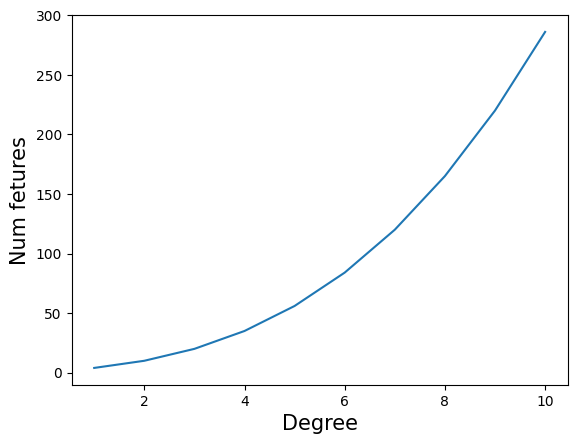

In [60]:
plt.figure()
plt.plot(range(1,11), num_fetures)
plt.xlabel('Degree', fontsize = 15)
plt.ylabel('Num fetures', fontsize = 15)
plt.show()

<div dir="rtl">


## נבצע שוב רגרסיה ליניארית כאשר הdegree משתנה 

In [48]:
# Section 3: Fit and Evaluate Polynomial Models
def fit_and_evaluate_poly(X_train, y_train, X_test, y_test, degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = sm.OLS(y_train, sm.add_constant(X_train_poly)).fit()
    y_pred = model.predict(sm.add_constant(X_test_poly))

    rss = np.sum((y_test - y_pred) ** 2)
    aic = model.aic
    bic = model.bic
    r2_adj = model.rsquared_adj

    return model, y_pred, rss, aic, bic, r2_adj, poly.get_feature_names_out()


In [49]:
# Section 4: Model Comparison
results = []
models = {}

for degree in range(1, 11):
    model, y_pred, rss, aic, bic, r2_adj, features = fit_and_evaluate_poly(X_train, y_train, X_test, y_test, degree)
    results.append({
        'Degree': degree,
        'AIC': aic,
        'BIC': bic,
        'Adjusted R^2': r2_adj
    })
    models[degree] = (model, y_pred, features)

results_df = pd.DataFrame(results)

results_df

,Degree,AIC,BIC,Adjusted R^2
0,1,3239.701537,3253.089967,0.914995
1,2,2703.402392,2736.873467,0.993568
2,3,2713.656784,2780.598935,0.993536
3,4,2731.911942,2839.019383,0.993287
4,5,2774.384457,2911.615866,0.992055
5,6,2916.586967,3077.248128,0.984739
6,7,3079.742428,3257.139127,0.967346
7,8,3264.161697,3454.946826,0.922377
8,9,3378.800811,3569.585940,0.866010
9,10,3466.241252,3660.373489,0.797410


In [50]:
styled_df = results_df.style.apply(highlight_max_red, subset=[ 'Adjusted R^2']) \
                    .apply(highlight_min_red, subset=['AIC', 'BIC'])

styled_df

,Degree,AIC,BIC,Adjusted R^2
0,1,3239.701537,3253.089967,0.914995
1,2,2703.402392,2736.873467,0.993568
2,3,2713.656784,2780.598935,0.993536
3,4,2731.911942,2839.019383,0.993287
4,5,2774.384457,2911.615866,0.992055
5,6,2916.586967,3077.248128,0.984739
6,7,3079.742428,3257.139127,0.967346
7,8,3264.161697,3454.946826,0.922377
8,9,3378.800811,3569.585940,0.866010
9,10,3466.241252,3660.373489,0.797410


<div dir="rtl">

### נסתכל על התוצאות עם המודל הטוב ביותר

### נבחר את הטוב היותר לפי זה שיש לו את הBIC הכי נמוך

### במקרה הזה יצא degree 2

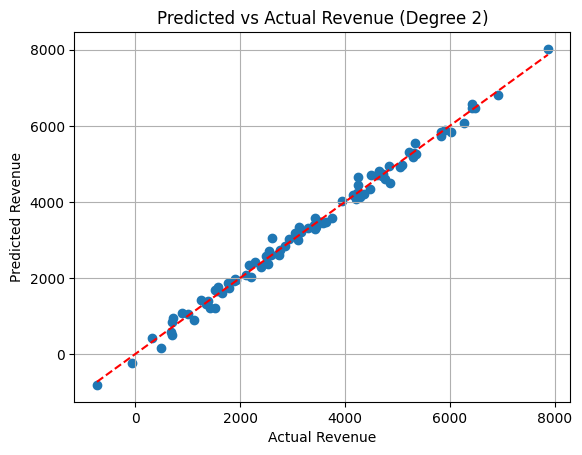

In [20]:
# Section 5: Visualize Predictions of Best Model
best_degree = results_df.sort_values('BIC').iloc[0]['Degree']
best_model, y_pred, features = models[int(best_degree)]

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title(f'Predicted vs Actual Revenue (Degree {int(best_degree)})')
plt.grid(True)
plt.show()


,Degree,AIC,BIC,Adjusted R^2
0,1,3239.701537,3253.089967,0.914995
1,2,2703.402392,2736.873467,0.993568
2,3,2713.656784,2780.598935,0.993536
3,4,2731.911942,2839.019383,0.993287
4,5,2774.384457,2911.615866,0.992055
5,6,2916.586967,3077.248128,0.984739
6,7,3079.742428,3257.139127,0.967346
7,8,3264.161697,3454.946826,0.922377
8,9,3378.800811,3569.585940,0.866010
9,10,3466.241252,3660.373489,0.797410


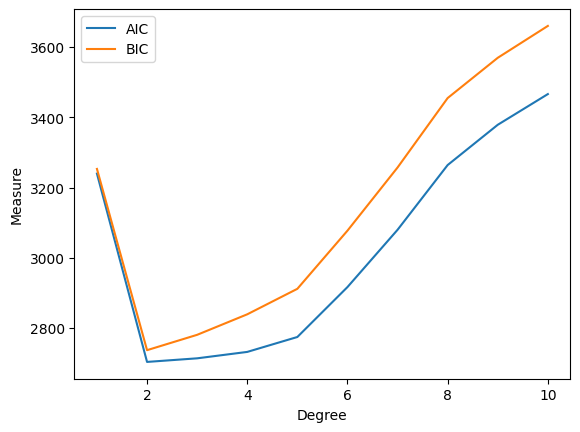

In [22]:
plt.figure()
plt.plot(results_df['Degree'], results_df['AIC'], label = 'AIC')
plt.plot(results_df['Degree'], results_df['BIC'], label = 'BIC')
plt.xlabel('Degree')
plt.ylabel('Measure')
plt.legend()
plt.show()

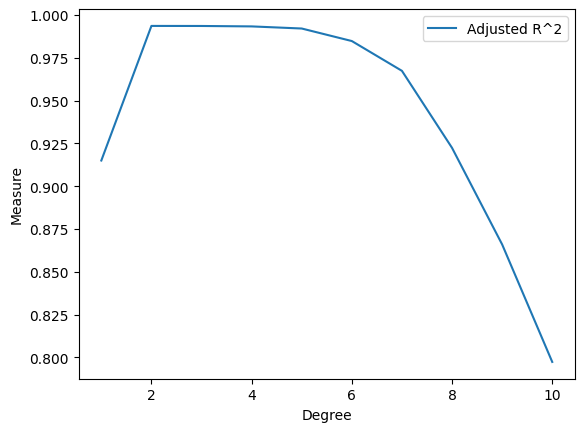

In [23]:
plt.figure()
plt.plot(results_df['Degree'], results_df['Adjusted R^2'], label = 'Adjusted R^2')
plt.xlabel('Degree')
plt.ylabel('Measure')
plt.legend()
plt.show()

<div dir="rtl">

### אבל לא נרצה לבחור את כל המשתנים מפולינום מסדר כלשהו אלא רק לבחור רק חלק מהם.

### ישנן שיטות סטטיסטיות היורסיטיות לבחור אילו משתנים נכנסנים למודל ואילו לא. 

### מה זה שיטה היוריסטית?

### זו שיטה שאינה מבטיחה פתרון אופטימאלי אך לרוב מאד יעילה ומוצאת פתרון קרוב לאופטימאלי. 

<div dir="rtl">

# Stepwise Selection — בחירת משתנים אוטומטית לרגרסיה

## 🔍 מה זה Stepwise Selection?

## Stepwise Selection היא שיטה אוטומטית לבחירת משתנים (features) עבור מודלים של רגרסיה. המטרה: למצוא תת־קבוצה של משתנים שמסבירה את המשתנה התלוי בצורה הטובה ביותר, תוך הימנעות מהוספת משתנים מיותרים.

---

## 🧩 איך זה עובד?

### ✅ 1. Forward Selection
#### מתחילים ממודל ללא משתנים. בכל שלב:
#### - מוסיפים את המשתנה עם ה־p-value הנמוך ביותר
#### - בתנאי שהוא נמוך מסף מסוים (למשל `p < 0.05`)
#### - ממשיכים עד שאין שיפור מובהק

### ✅ 2. Backward Elimination
#### מתחילים עם כל המשתנים. בכל שלב:
#### - מסירים את המשתנה עם ה־p-value הגבוה ביותר
#### - אם הוא מעל הסף (למשל `p > 0.05`)
#### - ממשיכים עד שכל המשתנים שנשארו מובהקים סטטיסטית

### ✅ 3. Stepwise (שילוב של השניים)
#### שילוב של שני התהליכים:
#### - בכל שלב אפשר **גם להוסיף** משתנים חדשים וגם **להסיר** משתנים שכבר בפנים
#### - משפר את האיזון ומונע הצמדות למודל גרוע

---



In [53]:
import statsmodels.api as sm

def stepwise_selection(X_train, y, degree, initial_list=[], threshold_in=0.05, threshold_out=0.05, verbose=True):

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    feature_names = poly.get_feature_names_out(['foot_traffic', 'ad_spend', 'competitors'])
    
    X = pd.DataFrame(X_train_poly, columns=feature_names)
     
    included = list(initial_list)
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pvals = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_column]])).fit()
            new_pvals[new_column] = model.pvalues[new_column]
        best_pval = new_pvals.min()
        if best_pval < threshold_in:
            best_feature = new_pvals.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f'Add  {best_feature} with p-value {best_pval:.6}')

        # backward step
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        pvals = model.pvalues.iloc[1:]  # exclude intercept
        worst_pval = pvals.max()
        if worst_pval > threshold_out:
            worst_feature = pvals.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print(f'Drop {worst_feature} with p-value {worst_pval:.6}')
        if not changed:
            break

    return included

<div dir="rtl">

##  נשתמש בפונקציה stepwise_selection 

### בהתחלה נתחיל מסדר 1 ואז נעלה

In [54]:
include_cols = stepwise_selection(X_train, y_train,1, verbose = False)
include_cols

['foot_traffic', 'ad_spend', 'competitors']

In [55]:
include_cols = stepwise_selection(X_train, y_train,2, verbose = False)
include_cols

['foot_traffic ad_spend',
 'competitors',
 'competitors^2',
 'ad_spend',
 'ad_spend^2',
 'foot_traffic']

In [56]:
include_cols = stepwise_selection(X_train, y_train,3, verbose = False)
include_cols

['foot_traffic ad_spend',
 'competitors',
 'competitors^2',
 'ad_spend',
 'ad_spend^2',
 'foot_traffic']

In [28]:
include_cols = stepwise_selection(X_train, y_train,4, verbose = False)
include_cols

['foot_traffic ad_spend',
 'competitors',
 'competitors^2',
 'ad_spend',
 'ad_spend^2',
 'foot_traffic']

<div dir="rtl">

### נשים לב כי כאשר הדרגה של הפולינום היא 2 ומעלה הוא תמיד בוחר את אותם משתנים

### המשמעות של זה היא שמשתנים מסדר פולינום 3 ומעלה כבר לא ממש משפיעים על המודל

### יחד עם זאת נראה כי הוא לא בחר את כל המשתנים מסדר גדול שני. אם נשמיט אותם אולי נצליח לשפר מדדים

In [57]:
model, y_pred, rss, aic, bic, r2_adj, feature_names = fit_and_evaluate_poly(X_train, y_train, X_test, y_test, 2)

In [64]:
dict1 = {'model': 'Polynom_2' , 'aic': aic, 'bic': bic, 'r2_adj':r2_adj}

In [65]:
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
feature_names = poly.get_feature_names_out(['foot_traffic', 'ad_spend', 'competitors'])
    
X_train_ = pd.DataFrame(X_train_poly, columns=feature_names)
X_test_ = pd.DataFrame(X_test_poly, columns=feature_names)

In [66]:
model = sm.OLS(y_train, sm.add_constant(X_train_[include_cols])).fit()
y_pred = model.predict(sm.add_constant(X_test_[include_cols]))

rss = np.sum((y_test.flatten() - y_pred) ** 2)
aic = model.aic
bic = model.bic
r2_adj = model.rsquared_adj

rss, aic, bic, r2_adj

dict2 = {'model': 'Polynom_2 filtered',  'aic': aic, 'bic': bic, 'r2_adj':r2_adj}

In [67]:
df_res = pd.DataFrame.from_dict([dict1, dict2])

df_res

,model,aic,bic,r2_adj
0,Polynom_2,2700.233867,2723.66362,0.993577
1,Polynom_2 filtered,2700.233867,2723.66362,0.993577


<div dir="rtl">

## המודל המפולטר עדיף בכל הפרטמרים